### 3. MLML Seawater Intake PCA

This notebook serves as a starting point for analysis of data from the [MLML seawater intake](http://pubdata.mlml.calstate.edu/seawater/), located just offshore of Moss Landing at 17m water depth. The data needed for this assignment are included in the `mlml_seawater_data` directory of this repository. 

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

We will use data from August 2016 because there is good coverage. The data file has dates in different formats, variables derived from sensor measurements and quality control flags. The data is loaded into a Pandas dataframe.

In [22]:
filename = 'data/mlml_seawater/2016-08.csv'
df = pd.read_csv(filename,parse_dates=[0,1])

In [23]:
df.head()

,utc_time,pst_time,unix_time,temp,temp_flg,cond,cond_flg,sal,sal_flg,fluor,...,osat_flg,tide,ph,ph_flg,phrawv,co2,temp_raw,cond_raw,fluoro_raw,trans_raw
0,2016-08-02 00:08:18+00:00,2016-08-01 16:08:18,1470096498,15.228153,9,0.959019,9,33.201665,9,6.694133,...,9,2.58,8.053234,9,2.693,NaN,NaN,NaN,NaN,NaN
1,2016-08-02 00:13:17+00:00,2016-08-01 16:13:17,1470096797,15.974306,9,0.967580,9,32.903808,9,6.643340,...,9,2.58,8.057628,9,2.694,NaN,NaN,NaN,NaN,NaN
2,2016-08-02 00:18:17+00:00,2016-08-01 16:18:17,1470097097,17.537585,1,0.991139,1,32.507648,1,2.078260,...,1,2.64,8.009297,1,2.683,NaN,NaN,NaN,NaN,NaN
3,2016-08-02 00:23:18+00:00,2016-08-01 16:23:18,1470097398,17.275320,1,0.994248,1,32.833492,3,2.122705,...,1,2.70,7.952179,1,2.670,NaN,NaN,NaN,NaN,NaN
4,2016-08-02 00:28:17+00:00,2016-08-01 16:28:17,1470097697,15.020288,1,0.954494,1,33.202816,1,1.284610,...,1,2.77,7.947785,1,2.669,NaN,NaN,NaN,NaN,NaN


The code below loops through different variables to 
1. create a subset of the data set based on quality control flags
2. plot the good data in this subset

The `ii` variable is `True` where all data meets quality control standards.

The data variables are:
* Temperature
* Salinity
* Dissolved oxygen
* pH
* Chlorophyll fluorescence (proxy for phytoplankton biomass)
* Beam attenuation (proxy for turbidity)
* Tide height (from Monterey)

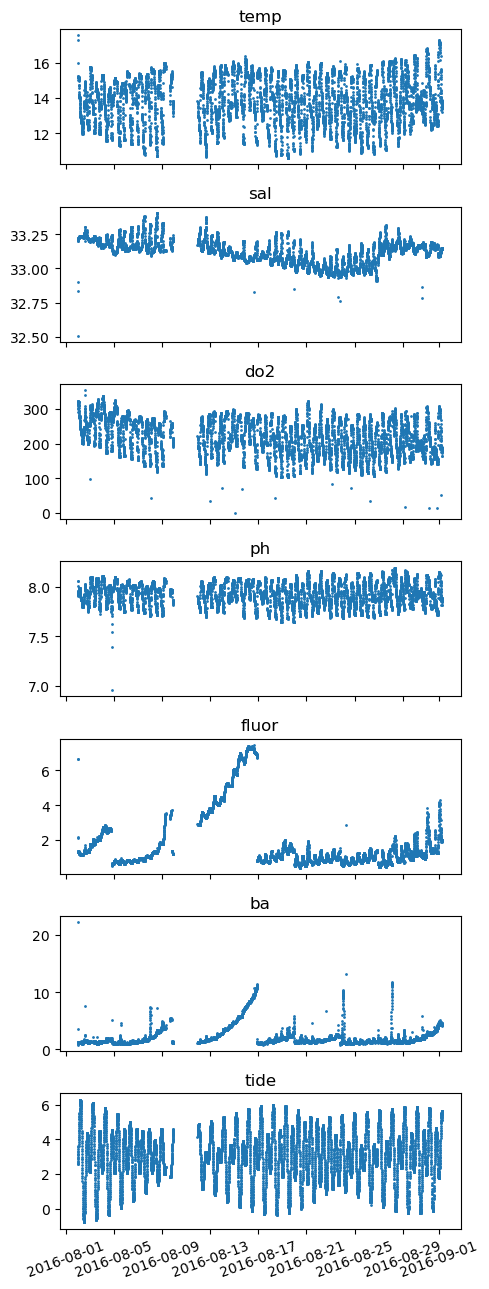

In [24]:
all_vars = ['temp','sal','do2','ph','fluor','ba','tide']

# Determine indices of data that meets quality control thresholds
# (flag values are equal to 1)
ii = np.ones(np.shape(df['temp_flg']),dtype=bool)
for var in all_vars:    # loop through all variables
    if var+'_flg' in vars():    # check if there is a flag variable
        goodi = df[var+'_flg']==1
        ii = ii & goodi 
ii = ii & (df['tide'] > -1000) # Remove invalid tide data

# Plot the good data
nvar = len(all_vars)
fig,axs = plt.subplots(nrows=nvar,sharex=True,figsize=(5,13))
for i,var in enumerate(all_vars):
    plt.subplot(nvar,1,i+1)
    plt.plot(df['utc_time'][ii],df[var][ii],'o',ms=1)
    plt.title(var)
    plt.xticks(rotation=20)
fig.tight_layout()

a. Create a data matrix containing the variables plotted above, and create a second matrix where each variable has been standardized by computing the z-scores. 

In [25]:
# insert code here
vars_pca = ['temp', 'sal', 'do2', 'ph', 'fluor', 'ba', 'tide']
data = df[vars_pca][ii].values
print(data)
np.shape(data)

[[ 15.22815323  33.20166459 313.31       ...   6.69413333  22.18435244
    2.58      ]
 [ 15.97430637  32.90380842 309.43       ...   6.64333968   0.86599784
    2.58      ]
 [ 17.53758471  32.5076482  301.31       ...   2.07826032   0.91301952
    2.64      ]
 ...
 [ 13.75070714  33.14453765 183.66       ...   1.94492698   4.57105084
    5.21      ]
 [ 13.73931909  33.14458678 183.49       ...   1.94492698   4.56305999
    5.14      ]
 [ 13.5971984   33.14934    178.67       ...   1.91318095   4.63118669
    5.14      ]]


(7892, 7)

In [26]:
np.mean(data, axis=0)
norm_data = (data - np.mean(data, axis=0))/np.std(data, axis=0, ddof=1)
np.shape(norm_data)

(7892, 7)

In [27]:
np.std(norm_data, axis =0, ddof=1)

array([1., 1., 1., 1., 1., 1., 1.])

In [28]:
np.mean(norm_data, axis =0)

array([-7.20266331e-18,  1.10344802e-14, -1.44053266e-16,  1.32529005e-15,
        2.01674573e-16,  1.44053266e-17,  1.17943612e-16])

b. Extract the eigenvalues and eigenvectors of the correlation matrix. Comment on what the columns of the eigenvector matrix represent mathematically.

In [29]:
# insert code here
R = np.cov(norm_data, rowvar=False)
print(R)

[[ 1.         -0.49471039  0.88794476  0.94495575  0.2161351   0.02026663
  -0.31876745]
 [-0.49471039  1.         -0.28963333 -0.42090551  0.01090438 -0.00942234
   0.0937578 ]
 [ 0.88794476 -0.28963333  1.          0.91926613  0.21510519 -0.06666646
  -0.28098306]
 [ 0.94495575 -0.42090551  0.91926613  1.          0.18040533 -0.07126514
  -0.35575488]
 [ 0.2161351   0.01090438  0.21510519  0.18040533  1.          0.74390834
  -0.05935141]
 [ 0.02026663 -0.00942234 -0.06666646 -0.07126514  0.74390834  1.
   0.02129139]
 [-0.31876745  0.0937578  -0.28098306 -0.35575488 -0.05935141  0.02129139
   1.        ]]


In [30]:
values, vector = linalg.eig(R)

In [31]:
values

array([3.26027859+0.j, 1.72630247+0.j, 0.91956337+0.j, 0.75793237+0.j,
       0.21024941+0.j, 0.04438604+0.j, 0.08128775+0.j])

In [32]:
np.real(values)

array([3.26027859, 1.72630247, 0.91956337, 0.75793237, 0.21024941,
       0.04438604, 0.08128775])

In [33]:
percentage_variance = (np.real(values)/np.sum(np.real(values)))*100
print(percentage_variance)

[46.57540842 24.66146383 13.13661956 10.82760523  3.00356307  0.63408627
  1.16125362]


In [34]:
vector

array([[-0.5363193 ,  0.02759702, -0.08177866, -0.09367113,  0.20921219,
        -0.61875825,  0.51914013],
       [ 0.291548  , -0.09283976,  0.60531148, -0.69073346,  0.18405358,
        -0.02933055,  0.16771951],
       [-0.50941112,  0.05229877,  0.04200975, -0.36173489,  0.01105425,
        -0.14443537, -0.7643065 ],
       [-0.53496459,  0.07929199,  0.01035879, -0.16988841,  0.06479905,
         0.76467269,  0.2993878 ],
       [-0.15485356, -0.68528383,  0.04444099, -0.09365956, -0.69574017,
        -0.03903897,  0.10040374],
       [-0.02284558, -0.71391147, -0.06732445,  0.16868181,  0.65827001,
         0.08940977, -0.12453451],
       [ 0.23910882, -0.04809659, -0.78646713, -0.56318127,  0.02568351,
         0.03426221,  0.05455688]])

*insert explanation here*
The columns of the eigenvctor matrix represents the PCA, and each column gives the weight each variable to that principal component (PC).

c. Sort the eigenvalues and eigenvectors so that they are arranged in order of decreasing variance (PC1 first, PC2 second, etc.). Hint: use `np.argsort` (see [example on Stack Overflow](https://stackoverflow.com/questions/8092920/sort-eigenvalues-and-associated-eigenvectors-after-using-numpy-linalg-eig-in-pyt)).

In [36]:
dec_var = np.argsort(np.real(values))[::-1]
sorted_val = np.real(values)[dec_var]
sorted_vec = np.real(vector)[:,dec_var]

In [37]:
sorted_val

array([3.26027859, 1.72630247, 0.91956337, 0.75793237, 0.21024941,
       0.08128775, 0.04438604])

In [38]:
sorted_vec

array([[-0.5363193 ,  0.02759702, -0.08177866, -0.09367113,  0.20921219,
         0.51914013, -0.61875825],
       [ 0.291548  , -0.09283976,  0.60531148, -0.69073346,  0.18405358,
         0.16771951, -0.02933055],
       [-0.50941112,  0.05229877,  0.04200975, -0.36173489,  0.01105425,
        -0.7643065 , -0.14443537],
       [-0.53496459,  0.07929199,  0.01035879, -0.16988841,  0.06479905,
         0.2993878 ,  0.76467269],
       [-0.15485356, -0.68528383,  0.04444099, -0.09365956, -0.69574017,
         0.10040374, -0.03903897],
       [-0.02284558, -0.71391147, -0.06732445,  0.16868181,  0.65827001,
        -0.12453451,  0.08940977],
       [ 0.23910882, -0.04809659, -0.78646713, -0.56318127,  0.02568351,
         0.05455688,  0.03426221]])

d. Determine the percentage of variance accounted for by the first two principal components (PCs).

In [39]:
per_var = (sorted_val/np.sum(sorted_val))*100
print(per_var)

[46.57540842 24.66146383 13.13661956 10.82760523  3.00356307  1.16125362
  0.63408627]


In [40]:
print('PC1 =', per_var[0])
print('PC1 =', per_var[1])

PC1 = 46.575408421162365
PC1 = 24.661463825104818


e. Compute and plot the factor loadings. This can be done in multiple ways, e.g. by plotting PC1 loadings vs. PC2 loadings, or by creating a line plot as in the BATS example shown in Glover, Jenkins and Doney. However you decide to plot, make sure it is clear which variable is represented by each point.

In [41]:
Lambda = np.diag(np.real(values))
Lambda

array([[3.26027859, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 1.72630247, 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.91956337, 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.75793237, 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.21024941,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.04438604, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.08128775]])

In [44]:
A = vector@np.sqrt(Lambda)
A

array([[-0.96839108,  0.03625941, -0.07842072, -0.08154944,  0.09592999,
        -0.13035995,  0.14801208],
       [ 0.52642611, -0.12198108,  0.58045659, -0.60134779,  0.08439402,
        -0.00617936,  0.04781852],
       [-0.91980503,  0.06871474,  0.04028477, -0.3149239 ,  0.0050687 ,
        -0.03042964, -0.21791148],
       [-0.96594498,  0.10418082,  0.00993345, -0.14790368,  0.02971228,
         0.1611012 ,  0.08535848],
       [-0.27960732, -0.90038641,  0.04261618, -0.08153936, -0.31901748,
        -0.00822473,  0.02862612],
       [-0.04125053, -0.93799993, -0.06456002,  0.14685323,  0.3018363 ,
         0.01883685, -0.03550604],
       [ 0.43174067, -0.06319355, -0.75417375, -0.49030173,  0.01177665,
         0.00721836,  0.01555472]])

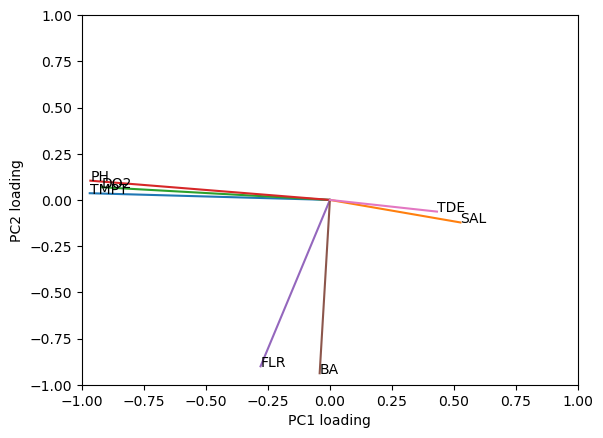

In [45]:
plt.figure()
plt.xlim([-1,1])
plt.ylim([-1,1])

plt.xlabel('PC1 loading')
plt.ylabel('PC2 loading')

variables = ['TMPT','SAL','DO2','PH', 'FLR', 'BA', 'TDE']
for i,txt in enumerate(variables):
    plt.plot([0,A[i,0]],[0,A[i,1]],'-')
    plt.text(A[i,0],A[i,1],txt)

f.  Compute the principal component scores, and plot the scores associated with PC1 and PC2.

In [47]:
score = norm_data@vector

In [48]:
np.shape(score)

(7892, 7)

Text(0.5, 1.0, 'PC1 vs PC2 Scores')

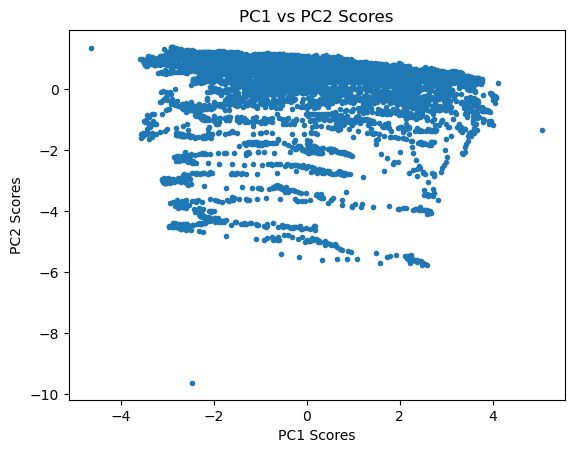

In [53]:
plt.figure()
plt.plot(score[:,0], score[:,1], '.',)
plt.xlabel('PC1 Scores')
plt.ylabel('PC2 Scores')
plt.title('PC1 vs PC2 Scores')

Text(0, 0.5, 'Temp ℃')

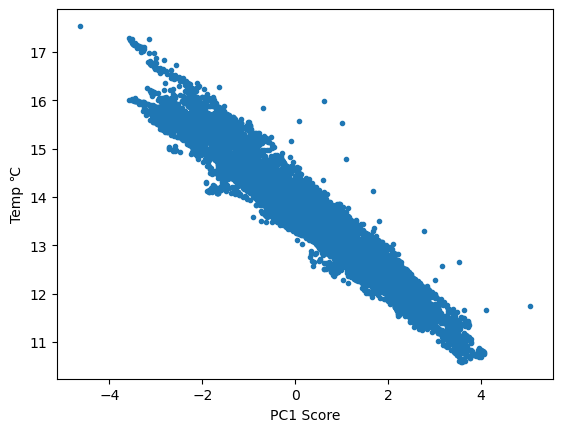

In [54]:
plt.figure()
plt.plot(score[:,0], df['temp'][ii], '.',)
plt.xlabel('PC1 Score')
plt.ylabel('Temp ℃')

g. In a paragraph, provide an oceanographic interpretation of the first two principal components based on the variances, factor loadings and scores.

PC1 explains the largest amount of variation in the water intake system, which looks to be salinity/ temperature/ph/etc., while PC2 is explaining the next or second largest amount of variation, looking to be primarily driven by fluoresence and beam attentuation. Based on the factor loadings plot, there seems to be shared positive interactions between certain variables.(1)PH, DO2, and temperature looks to be positvely related, while conversely, (2)Tide and Salinity seems to have positive interactions with one another, then (3)fluor and BA are positively related. Between these 3 groups, they all veer off in separate directions, emphasizing how little related or low affect they have on one another. The distribution of PC scores shows that the most variability occurs along PC1, maybe indicating that there's a lot of mixing or upwelling.